In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

master_df = pd.read_csv(
    "../data/processed/master_stock_data.csv"
)

In [72]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10374 entries, 0 to 10373
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     10374 non-null  object 
 1   Close    10374 non-null  float64
 2   High     10374 non-null  float64
 3   Low      10374 non-null  float64
 4   Open     10374 non-null  float64
 5   Volume   10374 non-null  int64  
 6   Company  10374 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 567.5+ KB


In [73]:
master_df['Date'] = pd.to_datetime(
    master_df['Date']
)

master_df.head()

,Date,Close,High,Low,Open,Volume,Company
0,2019-01-01,496.196411,498.985065,491.371684,498.077655,9746670,Reliance
1,2019-01-02,489.733856,498.852189,487.343595,493.319204,15628818,Reliance
2,2019-01-03,483.691895,493.363509,482.518910,490.220786,16288287,Reliance
3,2019-01-04,486.303436,488.870748,478.535167,485.750155,18516544,Reliance
4,2019-01-07,489.003540,495.067675,487.343638,489.999475,12060290,Reliance


In [74]:
master_df = master_df.sort_values(
    ['Company', 'Date']
)

master_df = master_df.reset_index(
    drop=True
)

In [75]:
master_df['Daily_Return'] = (
    master_df.groupby('Company')['Close']
    .pct_change()
)

In [76]:
master_df[
    ['Company','Date','Close','Daily_Return']
].head()

,Company,Date,Close,Daily_Return
0,HDFC_Bank,2019-01-01,496.185852,NaN
1,HDFC_Bank,2019-01-02,491.658508,-0.009124
2,HDFC_Bank,2019-01-03,487.801025,-0.007846
3,HDFC_Bank,2019-01-04,489.106018,0.002675
4,HDFC_Bank,2019-01-07,489.845154,0.001511


# ==================================================
# FEATURE ENGINEERING SECTION 1 - MOVING AVERAGES
Moving averages smooth price fluctuations and help the model understand trends.
# ==================================================

In [77]:
master_df['MA_7'] = (
    master_df.groupby('Company')['Close']
    .transform(lambda x: x.rolling(window=7).mean())
)

master_df['MA_21'] = (
    master_df.groupby('Company')['Close']
    .transform(lambda x: x.rolling(window=21).mean())
)

master_df['MA_50'] = (
    master_df.groupby('Company')['Close']
    .transform(lambda x: x.rolling(window=50).mean())
)

master_df.head()

,Date,Close,High,Low,Open,Volume,Company,Daily_Return,MA_7,MA_21,MA_50
0,2019-01-01,496.185852,496.855695,486.368852,491.462098,6373440,HDFC_Bank,NaN,NaN,NaN,NaN
1,2019-01-02,491.658508,496.047285,489.625800,494.961652,8134232,HDFC_Bank,-0.009124,NaN,NaN,NaN
2,2019-01-03,487.801025,491.600771,485.768317,490.665257,12771664,HDFC_Bank,-0.007846,NaN,NaN,NaN
3,2019-01-04,489.106018,491.658449,487.466035,488.597855,7287120,HDFC_Bank,0.002675,NaN,NaN,NaN
4,2019-01-07,489.845154,493.240726,489.233058,491.473632,5387012,HDFC_Bank,0.001511,NaN,NaN,NaN


In [78]:
master_df.tail()

,Date,Close,High,Low,Open,Volume,Company,Daily_Return,MA_7,MA_21,MA_50
10369,2025-12-23,954.691650,960.241576,953.512885,959.013708,5123287,SBI,-0.002463,955.393258,951.450044,933.549696
10370,2025-12-24,951.793884,959.996016,950.369546,955.968634,4105643,SBI,-0.003035,955.631818,950.764779,935.239242
10371,2025-12-26,949.190735,953.807529,947.668191,951.793838,3286321,SBI,-0.002735,956.354501,949.941520,936.994601
10372,2025-12-29,947.962891,951.744759,944.426656,949.780171,5267233,SBI,-0.001294,954.838963,949.576669,938.545643
10373,2025-12-30,956.214172,958.915481,942.511158,945.949187,15030644,SBI,0.008704,954.263620,949.317063,940.245012


In [79]:
master_df[['MA_7','MA_21','MA_50']].isnull().sum()

MA_7      36
MA_21    120
MA_50    294
dtype: int64

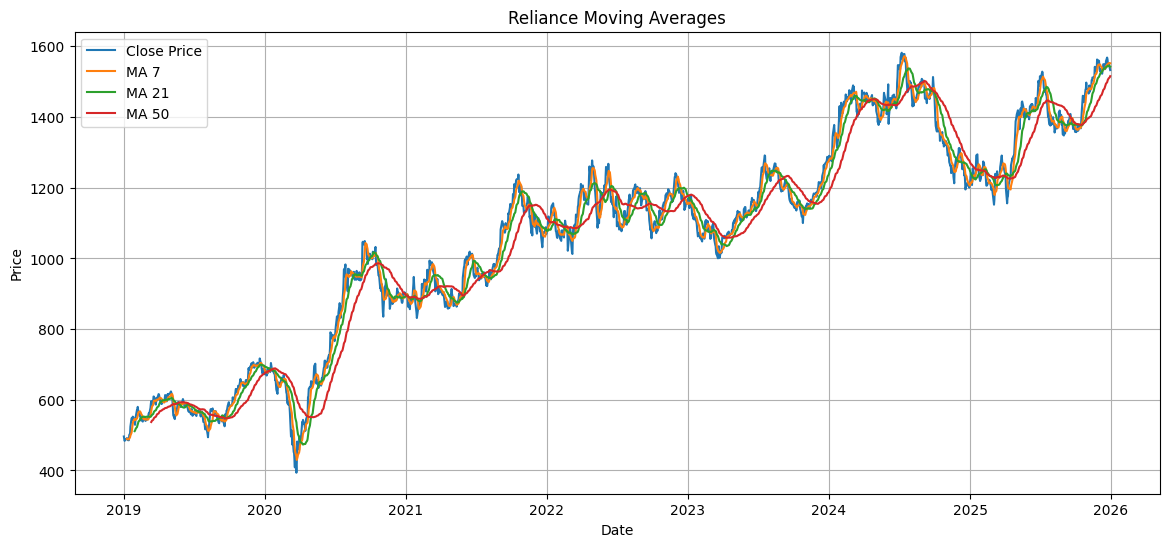

In [80]:
reliance_df = master_df[
    master_df['Company'] == 'Reliance'
]

plt.figure(figsize=(14,6))

plt.plot(
    reliance_df['Date'],
    reliance_df['Close'],
    label='Close Price'
)

plt.plot(
    reliance_df['Date'],
    reliance_df['MA_7'],
    label='MA 7'
)

plt.plot(
    reliance_df['Date'],
    reliance_df['MA_21'],
    label='MA 21'
)

plt.plot(
    reliance_df['Date'],
    reliance_df['MA_50'],
    label='MA 50'
)

plt.title('Reliance Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

plt.show()

# ==================================================
# FEATURE ENGINEERING SECTION 2 - LAG FEATURES
"What happened yesterday often influences today."

Why do we create these?

Suppose today:

Yesterday Price = 500
5 Days Ago = 480
10 Days Ago = 450

The model can learn:

450 → 480 → 500

Price is moving upward.

This is called momentum.

Without lag features:

Model sees only today's price.

With lag features:

Model sees price history.
# ==================================================

In [81]:
master_df['Lag_1'] = (
    master_df.groupby('Company')['Close']
    .shift(1)
)

master_df['Lag_5'] = (
    master_df.groupby('Company')['Close']
    .shift(5)
)

master_df['Lag_10'] = (
    master_df.groupby('Company')['Close']
    .shift(10)
)

master_df.head()

,Date,Close,High,Low,Open,Volume,Company,Daily_Return,MA_7,MA_21,MA_50,Lag_1,Lag_5,Lag_10
0,2019-01-01,496.185852,496.855695,486.368852,491.462098,6373440,HDFC_Bank,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-02,491.658508,496.047285,489.625800,494.961652,8134232,HDFC_Bank,-0.009124,NaN,NaN,NaN,496.185852,NaN,NaN
2,2019-01-03,487.801025,491.600771,485.768317,490.665257,12771664,HDFC_Bank,-0.007846,NaN,NaN,NaN,491.658508,NaN,NaN
3,2019-01-04,489.106018,491.658449,487.466035,488.597855,7287120,HDFC_Bank,0.002675,NaN,NaN,NaN,487.801025,NaN,NaN
4,2019-01-07,489.845154,493.240726,489.233058,491.473632,5387012,HDFC_Bank,0.001511,NaN,NaN,NaN,489.106018,NaN,NaN


In [82]:
master_df[['Lag_1','Lag_5','Lag_10']].isnull().sum()

Lag_1      6
Lag_5     30
Lag_10    60
dtype: int64

In [83]:
reliance_df = master_df[
    master_df['Company'] == 'Reliance'
]

reliance_df[
    ['Date','Close','Lag_1','Lag_5']
].head(10)

,Date,Close,Lag_1,Lag_5
6916,2019-01-01,496.196411,NaN,NaN
6917,2019-01-02,489.733856,496.196411,NaN
6918,2019-01-03,483.691895,489.733856,NaN
6919,2019-01-04,486.303436,483.691895,NaN
6920,2019-01-07,489.003540,486.303436,NaN
6921,2019-01-08,488.959320,489.003540,496.196411
6922,2019-01-09,491.659393,488.959320,489.733856
6923,2019-01-10,490.220764,491.659393,483.691895
6924,2019-01-11,486.037842,490.220764,486.303436
6925,2019-01-14,485.484650,486.037842,489.003540


# FEATURE ENGINEERING SECTION 3 - MOMENTUM FEATURES

In [84]:
master_df['Momentum_5'] = (
    master_df.groupby('Company')['Close']
    .pct_change(5)
)

master_df['Momentum_21'] = (
    master_df.groupby('Company')['Close']
    .pct_change(21)
)

In [85]:
master_df[
    ['Company','Date','Close',
     'Momentum_5',
     'Momentum_21']
].head(25)

,Company,Date,Close,Momentum_5,Momentum_21
0,HDFC_Bank,2019-01-01,496.185852,NaN,NaN
1,HDFC_Bank,2019-01-02,491.658508,NaN,NaN
2,HDFC_Bank,2019-01-03,487.801025,NaN,NaN
3,HDFC_Bank,2019-01-04,489.106018,NaN,NaN
4,HDFC_Bank,2019-01-07,489.845154,NaN,NaN
5,HDFC_Bank,2019-01-08,485.768219,-0.020995,NaN
6,HDFC_Bank,2019-01-09,488.955963,-0.005497,NaN
7,HDFC_Bank,2019-01-10,487.038727,-0.001563,NaN
8,HDFC_Bank,2019-01-11,487.824036,-0.002621,NaN
9,HDFC_Bank,2019-01-14,485.456482,-0.008959,NaN


# FEATURE ENGINEERING SECTION 4-Price vs MA Features

In [86]:
master_df['Price_vs_MA7'] = (
    master_df['Close']
    / master_df['MA_7']
)

master_df['Price_vs_MA21'] = (
    master_df['Close']
    / master_df['MA_21']
)

master_df['Price_vs_MA50'] = (
    master_df['Close']
    / master_df['MA_50']
)

# ==================================================
# FEATURE ENGINEERING SECTION 5 - ROLLING STATISTICS
# ==================================================

# Creating Rolling Volatility Features

In [87]:
master_df['Rolling_Std_7'] = (
    master_df.groupby('Company')['Close']
    .transform(lambda x: x.rolling(window=7).std())
)

master_df['Rolling_Std_21'] = (
    master_df.groupby('Company')['Close']
    .transform(lambda x: x.rolling(window=21).std())
)

In [88]:
# Volatility Ratio

master_df['Vol_Ratio'] = (
    master_df['Rolling_Std_7']
    / master_df['Rolling_Std_21']
)

In [89]:
master_df[
    [
        'Company',
        'Date',
        'Rolling_Std_7',
        'Rolling_Std_21',
        'Vol_Ratio'
    ]
].head()

,Company,Date,Rolling_Std_7,Rolling_Std_21,Vol_Ratio
0,HDFC_Bank,2019-01-01,NaN,NaN,NaN
1,HDFC_Bank,2019-01-02,NaN,NaN,NaN
2,HDFC_Bank,2019-01-03,NaN,NaN,NaN
3,HDFC_Bank,2019-01-04,NaN,NaN,NaN
4,HDFC_Bank,2019-01-07,NaN,NaN,NaN


In [92]:
master_df[
    [
        'Rolling_Std_7',
        'Rolling_Std_21',
        'Vol_Ratio'
    ]
].isnull().sum()

Rolling_Std_7      36
Rolling_Std_21    120
Vol_Ratio         120
dtype: int64

1. Rolling Mean captures short-term and medium-term trends.
2. Rolling Standard Deviation captures recent volatility.
3. Higher Rolling Std indicates unstable market behavior.
4. These features help machine learning models understand both trend and risk.

In [93]:
master_df.head(30)

,Date,Close,High,Low,Open,Volume,Company,Daily_Return,MA_7,MA_21,...,Lag_5,Lag_10,Momentum_5,Momentum_21,Price_vs_MA7,Price_vs_MA21,Price_vs_MA50,Rolling_Std_7,Rolling_Std_21,Vol_Ratio
0,2019-01-01,496.185852,496.855695,486.368852,491.462098,6373440,HDFC_Bank,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-02,491.658508,496.047285,489.625800,494.961652,8134232,HDFC_Bank,-0.009124,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-03,487.801025,491.600771,485.768317,490.665257,12771664,HDFC_Bank,-0.007846,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-04,489.106018,491.658449,487.466035,488.597855,7287120,HDFC_Bank,0.002675,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-07,489.845154,493.240726,489.233058,491.473632,5387012,HDFC_Bank,0.001511,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2019-01-08,485.768219,490.503477,484.301421,490.156995,8343460,HDFC_Bank,-0.008323,NaN,NaN,...,496.185852,NaN,-0.020995,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2019-01-09,488.955963,490.006971,485.675941,489.233138,8568628,HDFC_Bank,0.006562,489.902963,NaN,...,491.658508,NaN,-0.005497,NaN,0.998067,NaN,NaN,3.306714,NaN,NaN
7,2019-01-10,487.038727,490.572858,483.377540,489.002127,7691540,HDFC_Bank,-0.003921,488.596231,NaN,...,487.801025,NaN,-0.001563,NaN,0.996812,NaN,NaN,1.931427,NaN,NaN
8,2019-01-11,487.824036,490.619016,486.923204,488.262947,6408040,HDFC_Bank,0.001612,488.048449,NaN,...,489.106018,NaN,-0.002621,NaN,0.999540,NaN,NaN,1.384482,NaN,NaN
9,2019-01-14,485.456482,487.362135,484.717331,487.362135,4855160,HDFC_Bank,-0.004853,487.713514,NaN,...,489.845154,NaN,-0.008959,NaN,0.995372,NaN,NaN,1.701595,NaN,NaN


# FEATURE ENGINEERING SECTION 6 Volume

In [94]:
master_df['Volume_MA7'] = (
    master_df.groupby('Company')['Volume']
    .transform(
        lambda x: x.rolling(7).mean()
    )
)

master_df['Volume_Ratio'] = (
    master_df['Volume']
    / master_df['Volume_MA7']
)

# FEATURE ENGINEERING SECTION 7 — CREATE TARGET VARIABLE

# Step 1: Create Tomorrow's Close Price

In [95]:
master_df['Range_Pct'] = (
    (master_df['High'] - master_df['Low'])
    / master_df['Close']
)

In [96]:
master_df['Open_Close_Pct'] = (
    (master_df['Close'] - master_df['Open'])
    / master_df['Open']
)

In [97]:
master_df['Target'] = (
    master_df.groupby('Company')['Close']
    .shift(-1)
)

master_df[['Company','Date','Close','Target']].head(10)

,Company,Date,Close,Target
0,HDFC_Bank,2019-01-01,496.185852,491.658508
1,HDFC_Bank,2019-01-02,491.658508,487.801025
2,HDFC_Bank,2019-01-03,487.801025,489.106018
3,HDFC_Bank,2019-01-04,489.106018,489.845154
4,HDFC_Bank,2019-01-07,489.845154,485.768219
5,HDFC_Bank,2019-01-08,485.768219,488.955963
6,HDFC_Bank,2019-01-09,488.955963,487.038727
7,HDFC_Bank,2019-01-10,487.038727,487.824036
8,HDFC_Bank,2019-01-11,487.824036,485.456482
9,HDFC_Bank,2019-01-14,485.456482,490.133942


# Step 2: Check Missing Values

In [98]:
master_df['Target'].isnull().sum()

np.int64(6)

In [99]:
master_df = master_df.dropna()
master_df.isnull().sum().sum()

np.int64(0)

In [100]:
master_df[
    ['Date','Company','Close','Target']
].head(10)

,Date,Company,Close,Target
49,2019-03-13,HDFC_Bank,514.306824,513.891113
50,2019-03-14,HDFC_Bank,513.891113,520.416565
51,2019-03-15,HDFC_Bank,520.416565,522.368347
52,2019-03-18,HDFC_Bank,522.368347,523.823547
53,2019-03-19,HDFC_Bank,523.823547,531.041931
54,2019-03-20,HDFC_Bank,531.041931,525.763855
55,2019-03-22,HDFC_Bank,525.763855,526.953430
56,2019-03-25,HDFC_Bank,526.953430,533.894653
57,2019-03-26,HDFC_Bank,533.894653,531.145813
58,2019-03-27,HDFC_Bank,531.145813,531.919739


In [101]:
master_df = master_df.dropna()
master_df = master_df.reset_index(drop=True)

master_df.head()

,Date,Close,High,Low,Open,Volume,Company,Daily_Return,MA_7,MA_21,...,Price_vs_MA21,Price_vs_MA50,Rolling_Std_7,Rolling_Std_21,Vol_Ratio,Volume_MA7,Volume_Ratio,Range_Pct,Open_Close_Pct,Target
0,2019-03-13,514.306824,516.027675,501.729527,502.399370,57166348,HDFC_Bank,0.025587,494.712450,488.937199,...,1.051887,1.053837,10.000527,7.742725,1.291603,1.700591e+07,3.361557,0.027801,0.023701,513.891113
1,2019-03-14,513.891113,519.146096,510.622652,518.534000,15379864,HDFC_Bank,-0.000808,498.594696,489.873250,...,1.049029,1.052222,11.535659,9.421351,1.224417,1.751200e+07,0.878247,0.016586,-0.008954,520.416565
2,2019-03-15,520.416565,522.010361,514.653419,515.334823,12763088,HDFC_Bank,0.012698,503.503213,491.229482,...,1.059416,1.064330,12.574926,11.543940,1.089310,1.812700e+07,0.704093,0.014137,0.009861,522.368347
3,2019-03-18,522.368347,529.344181,519.030578,522.472281,14358720,HDFC_Bank,0.003750,507.956342,492.893146,...,1.059800,1.066813,13.002543,13.346031,0.974263,1.872041e+07,0.767009,0.019744,-0.000199,523.823547
4,2019-03-19,523.823547,525.706079,519.954495,524.227777,11957992,HDFC_Bank,0.002786,512.561244,494.731152,...,1.058804,1.068270,11.901308,14.814323,0.803365,1.942106e+07,0.615723,0.010980,-0.000771,531.041931


In [102]:
master_df.to_csv(
    '../data/processed/stock_features.csv',
    index=False
)